### Import Libraries

In [1]:
# Import required libraries for SVM classification
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


### Load Iris Dataset (Convert to Binary Classification)

In [4]:
# Load iris dataset
df = pd.read_csv('1) iris.csv')

print("Original dataset shape:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())

# Convert to binary classification: setosa (0) vs non-setosa (1)
df_binary = df.copy()
df_binary['target'] = df_binary['species'].apply(lambda x: 0 if x == 'setosa' else 1)

# Separate features and binary target
X = df_binary.drop(['species', 'target'], axis=1)
y = df_binary['target']

print("\nBinary Classification Setup:")
print(f"  Class 0 (setosa): {(y==0).sum()} samples")
print(f"  Class 1 (non-setosa): {(y==1).sum()} samples")
print(f"\nFeatures shape: {X.shape}")

Original dataset shape: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Binary Classification Setup:
  Class 0 (setosa): 50 samples
  Class 1 (non-setosa): 100 samples

Features shape: (150, 4)


### Explore Dataset

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64

Basic Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000   

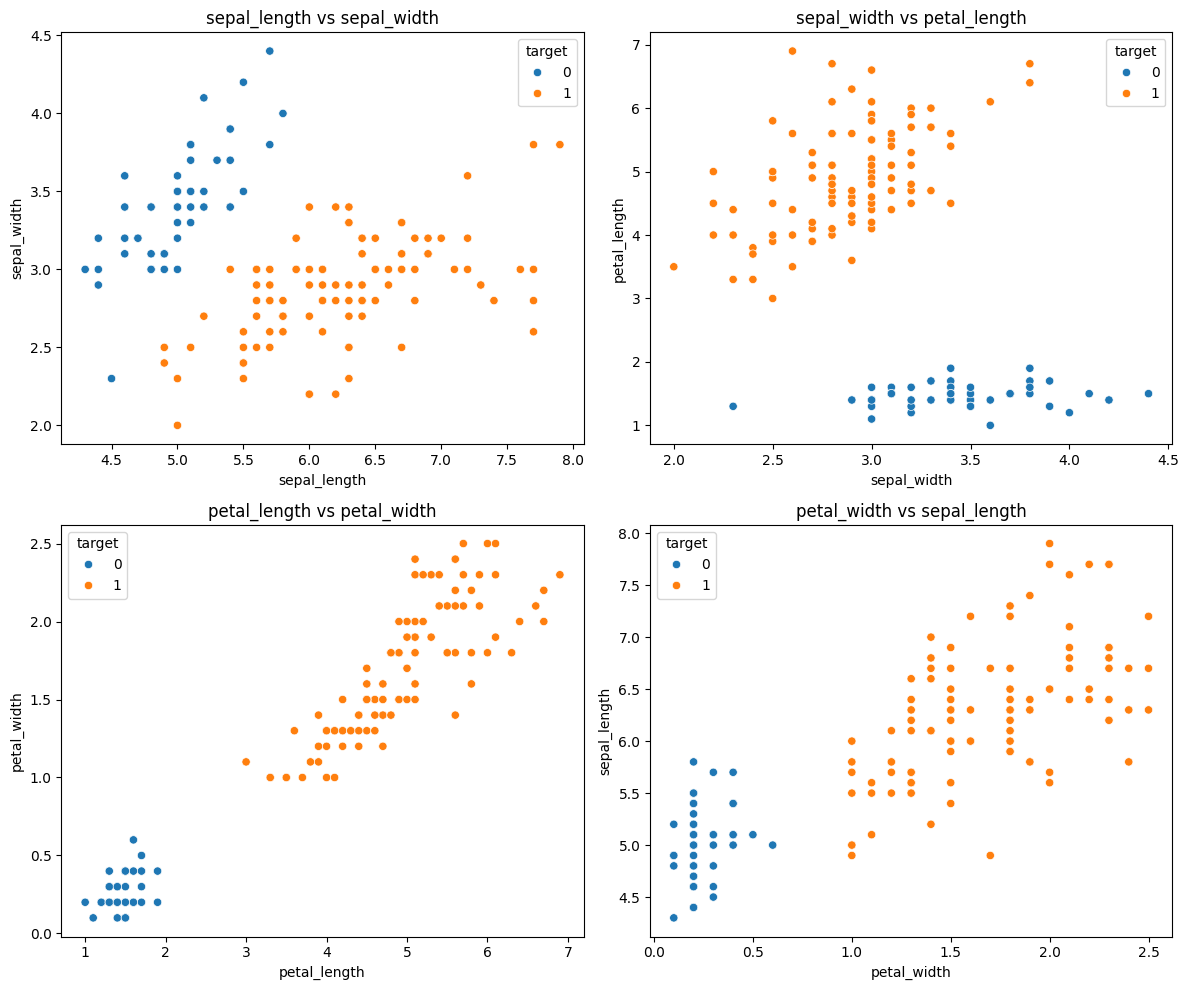

In [5]:
print("Dataset Info:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum())

print("\nBasic Statistics:")
print(X.describe())

# Visualize feature distributions by class
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, col in enumerate(X.columns):
    ax = axes[idx//2, idx%2]
    sns.scatterplot(data=df_binary, x=col, y=X.columns[(idx+1)%4], hue='target', ax=ax)
    ax.set_title(f'{col} vs {X.columns[(idx+1)%4]}')
plt.tight_layout()
plt.show()

### Preprocess Data (Scale Features - Critical for SVM)

In [6]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (SVM is sensitive to feature scales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Preprocessing Complete ===")
print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Testing set: {X_test_scaled.shape[0]} samples")
print(f"\nFeature scaling applied (StandardScaler)")

=== Preprocessing Complete ===
Training set: 120 samples
Testing set: 30 samples

Feature scaling applied (StandardScaler)


### Train SVM with Different Kernels

In [7]:
# Train SVM with linear kernel
svm_linear = SVC(kernel='linear', random_state=42, probability=True)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

# Train SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', random_state=42, probability=True)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# Evaluate Linear Kernel
print("=== Linear Kernel Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_linear):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_linear):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_linear):.4f}")
print(f"AUC: {roc_auc_score(y_test, svm_linear.predict_proba(X_test_scaled)[:,1]):.4f}")

# Evaluate RBF Kernel
print("\n=== RBF Kernel Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rbf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rbf):.4f}")
print(f"AUC: {roc_auc_score(y_test, svm_rbf.predict_proba(X_test_scaled)[:,1]):.4f}")

=== Linear Kernel Performance ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
AUC: 1.0000

=== RBF Kernel Performance ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
AUC: 1.0000


### Compare Kernel Performance

In [8]:
# Create comparison table
comparison = pd.DataFrame({
    'Kernel': ['Linear', 'RBF'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rbf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rbf)
    ],
    'AUC': [
        roc_auc_score(y_test, svm_linear.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, svm_rbf.predict_proba(X_test_scaled)[:,1])
    ]
})

print("=== Kernel Comparison ===")
print(comparison.round(4))

print("\nInterpretation:")
print("- Linear kernel: Works well for linearly separable data, simpler decision boundary")
print("- RBF kernel: Can capture non-linear patterns, more flexible")

=== Kernel Comparison ===
   Kernel  Accuracy  Precision  Recall  AUC
0  Linear       1.0        1.0     1.0  1.0
1     RBF       1.0        1.0     1.0  1.0

Interpretation:
- Linear kernel: Works well for linearly separable data, simpler decision boundary
- RBF kernel: Can capture non-linear patterns, more flexible


### Visualize Decision Boundary (2D using Two Features)

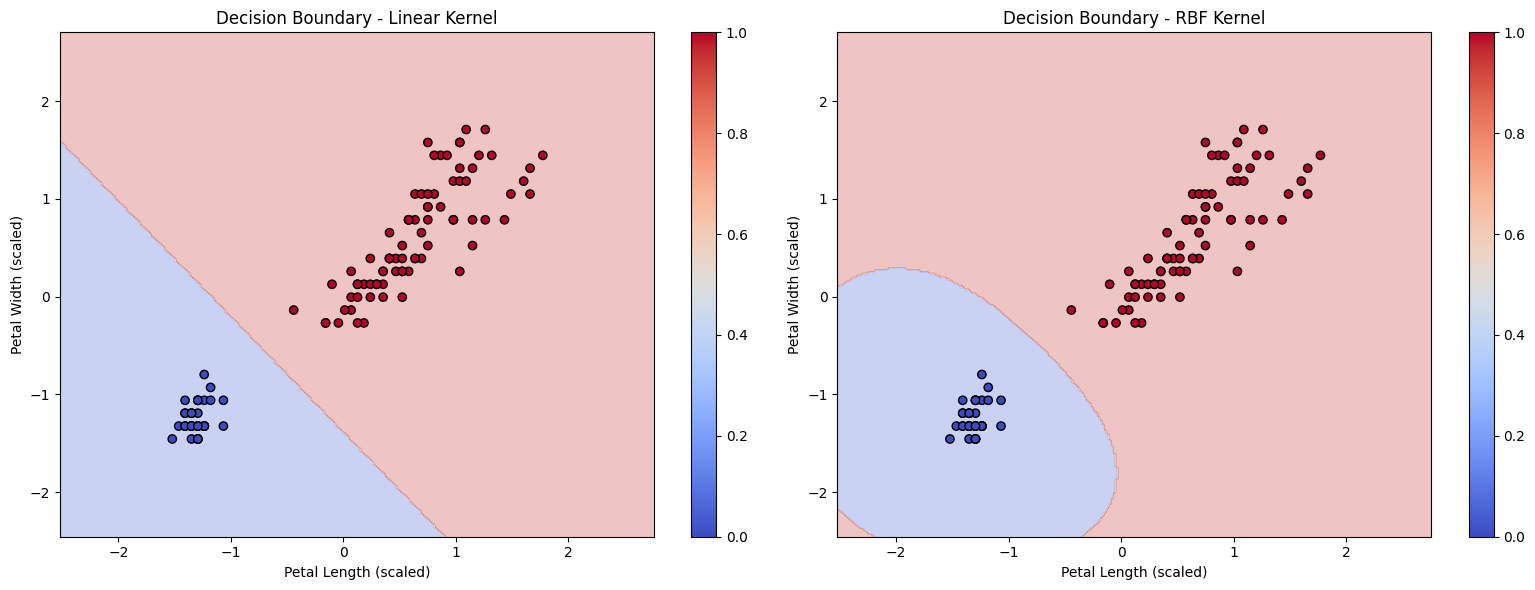

In [9]:
# Use two features (petal length and width) for 2D visualization
features_2d = ['petal_length', 'petal_width']
X_2d = df_binary[features_2d]
y_2d = df_binary['target']

# Split and scale 2D data
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)
scaler_2d = StandardScaler()
X2_train_s = scaler_2d.fit_transform(X2_train)
X2_test_s = scaler_2d.transform(X2_test)

# Train SVM models on 2D data
svm_linear_2d = SVC(kernel='linear', random_state=42)
svm_linear_2d.fit(X2_train_s, y2_train)

svm_rbf_2d = SVC(kernel='rbf', random_state=42)
svm_rbf_2d.fit(X2_train_s, y2_train)

# Create mesh grid for decision boundary
h = 0.02
x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh grid for both kernels
Z_linear = svm_linear_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)

Z_rbf = svm_rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

# Plot decision boundaries
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear kernel
ax1.contourf(xx, yy, Z_linear, alpha=0.3, cmap='coolwarm')
scatter1 = ax1.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train, cmap='coolwarm', edgecolors='k')
ax1.set_xlabel('Petal Length (scaled)')
ax1.set_ylabel('Petal Width (scaled)')
ax1.set_title('Decision Boundary - Linear Kernel')
plt.colorbar(scatter1, ax=ax1)

# RBF kernel
ax2.contourf(xx, yy, Z_rbf, alpha=0.3, cmap='coolwarm')
scatter2 = ax2.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train, cmap='coolwarm', edgecolors='k')
ax2.set_xlabel('Petal Length (scaled)')
ax2.set_ylabel('Petal Width (scaled)')
ax2.set_title('Decision Boundary - RBF Kernel')
plt.colorbar(scatter2, ax=ax2)

plt.tight_layout()
plt.show()

### Classification Report for Best Model

In [10]:
# Determine best model based on AUC
auc_linear = roc_auc_score(y_test, svm_linear.predict_proba(X_test_scaled)[:,1])
auc_rbf = roc_auc_score(y_test, svm_rbf.predict_proba(X_test_scaled)[:,1])

if auc_linear >= auc_rbf:
    best_model = svm_linear
    best_kernel = 'Linear'
    best_pred = y_pred_linear
else:
    best_model = svm_rbf
    best_kernel = 'RBF'
    best_pred = y_pred_rbf

print(f"=== Best Model: {best_kernel} Kernel ===")
print(f"\nClassification Report:")
print(classification_report(y_test, best_pred, target_names=['Setosa (0)', 'Non-Setosa (1)']))

print(f"\nKey SVM Insights:")
print("- SVM finds optimal hyperplane that maximizes margin between classes")
print("- Linear kernel: Good for linearly separable data, fewer support vectors")
print("- RBF kernel: Can model complex non-linear boundaries via kernel trick")

=== Best Model: Linear Kernel ===

Classification Report:
                precision    recall  f1-score   support

    Setosa (0)       1.00      1.00      1.00        10
Non-Setosa (1)       1.00      1.00      1.00        20

      accuracy                           1.00        30
     macro avg       1.00      1.00      1.00        30
  weighted avg       1.00      1.00      1.00        30


Key SVM Insights:
- SVM finds optimal hyperplane that maximizes margin between classes
- Linear kernel: Good for linearly separable data, fewer support vectors
- RBF kernel: Can model complex non-linear boundaries via kernel trick
